<a href="https://colab.research.google.com/github/Divanshu-Bansal/Machine-Learning-Algorithms/blob/master/Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Solving the Regression Problem

Will predict the value of FWI on the basis of other features

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
!pwd

/content


In [ ]:
!git clone https://github.com/Divanshu-Bansal/Algerian_forest_fires_datase_Ridge_Lasso_Elastic_Regression.git

Cloning into 'Algerian_forest_fires_datase_Ridge_Lasso_Elastic_Regression'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 27 (delta 11), reused 5 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 413.14 KiB | 6.17 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [ ]:
%cd Algerian_forest_fires_datase_Ridge_Lasso_Elastic_Regression/

/content/Algerian_forest_fires_datase_Ridge_Lasso_Elastic_Regression


In [ ]:
!ls

Algerian_forest_fires_cleaned_dataset	  EDA.ipynb		README.md
Algerian_forest_fires_dataset_UPDATE.csv  Model_Training.ipynb


In [ ]:
df = pd.read_csv("Algerian_forest_fires_cleaned_dataset")

In [ ]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
df.drop(["day","month","year"], axis = 1, inplace = True)

In [ ]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [ ]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [ ]:
df['Classes']=np.where(df['Classes'].str.contains("not fire"), 0, 1)

In [ ]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


Divide Features into Independent and Dependent Features

In [ ]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
X=df.drop('FWI',axis=1)
y=df['FWI']

In [ ]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0.0


In [ ]:
y

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5
...,...
238,6.5
239,0.0
240,0.2
241,0.7


Train and Test Split

In [ ]:
import sklearn.model_selection
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.25, random_state=42 )

In [ ]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

Feature Selection based on Correlartion

In [ ]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

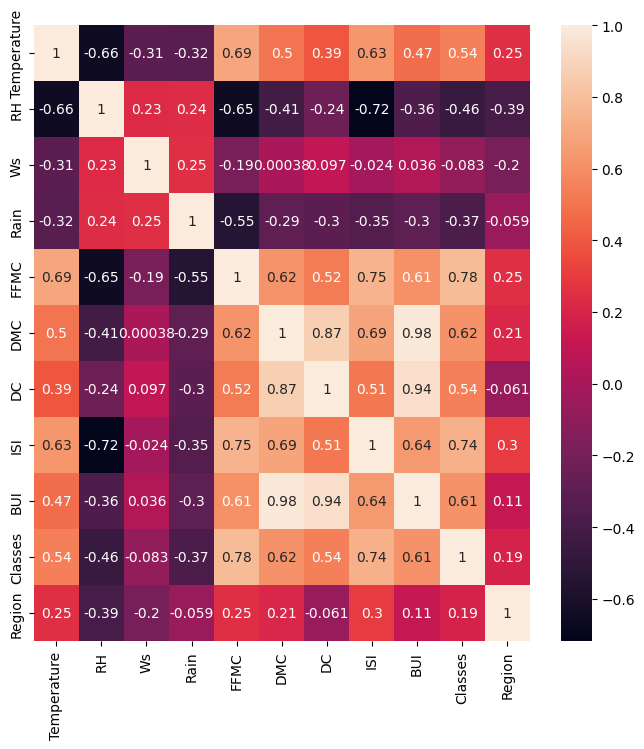

In [ ]:
plt.figure(figsize=(8,8))
corr = X_train.corr()
sns.heatmap(corr,annot=True)

In [ ]:
def correlation(dataset, threshold):
  corr_cols = set()
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j]) > threshold:
        colname = corr_matrix.columns[i]
        corr_cols.add(colname)
  return corr_cols

In [ ]:
cols = correlation(X_train,0.85)

In [ ]:
# Dropping the features with correlation more than 0.85

X_train.drop(cols, axis=1, inplace = True)
X_test.drop(cols, axis=1, inplace = True)

In [ ]:
X_train.shape,X_test.shape

((182, 9), (61, 9))

Feature Scaling or standardization

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Box plots to understand effect of Standard Scaling

Text(0.5, 1.0, 'X_train after scaling')

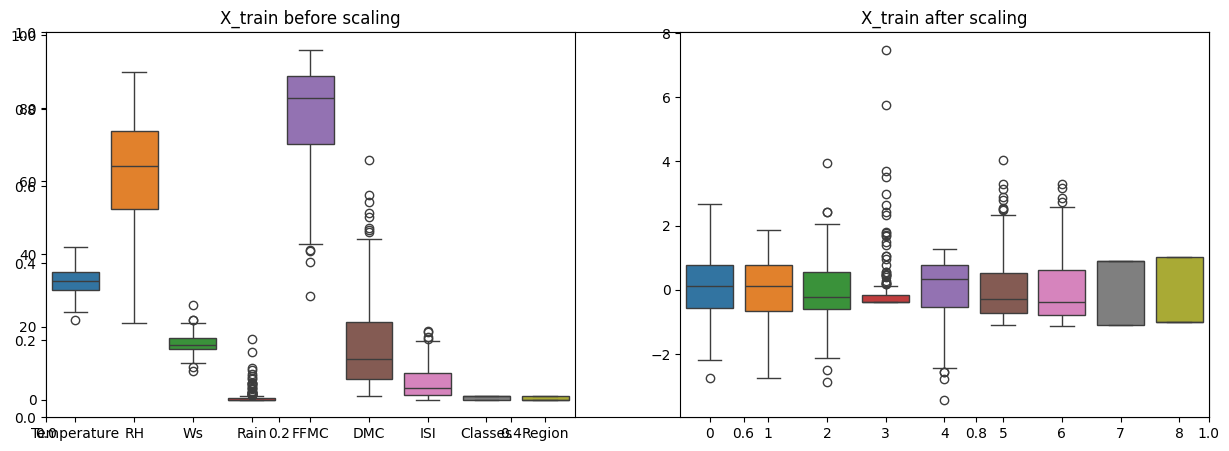

In [ ]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train after scaling")


## Linear Regression

Mean Absolute Error: 0.9939450225331374
r2 Score: 0.9607056657860652


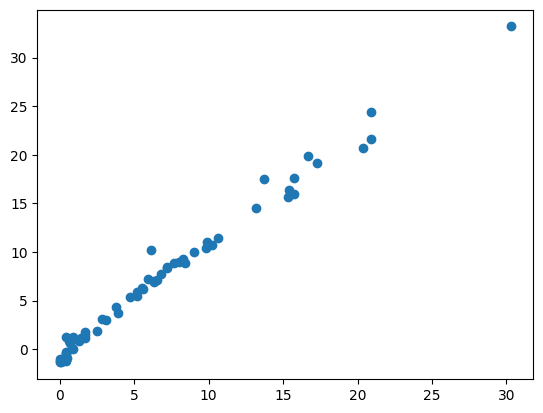

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred = linreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:", mae)
print("r2 Score:", r2)
plt.scatter(y_test,y_pred)

## Lasso Regression

Mean Absolute Error: 0.9605020166901078
r2 Score: 0.9692970913627958


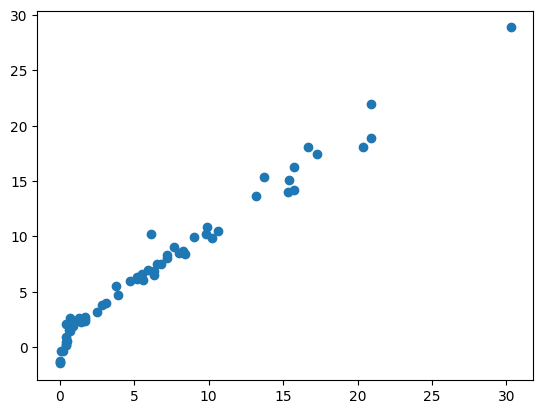

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasreg = Lasso()
lasreg.fit(X_train_scaled,y_train)
y_pred= lasreg.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:", mae)
print("r2 Score:", r2)
plt.scatter(y_test,y_pred)

## Ridge Regression

Mean Absolute Error: 0.9862070802884405
r2 Score: 0.9616458508455313


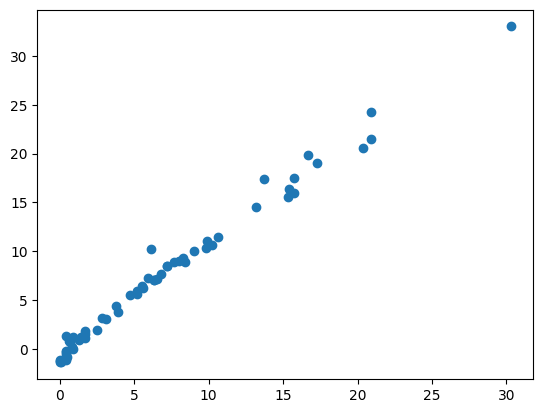

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridreg = Ridge()
ridreg.fit(X_train_scaled,y_train)
y_pred=ridreg.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:", mae)
print("r2 Score:", r2)
plt.scatter(y_test,y_pred)

## Elastic Net Regression

Mean Absolute Error: 1.6511868133560943
r2 Score: 0.9081701979826985


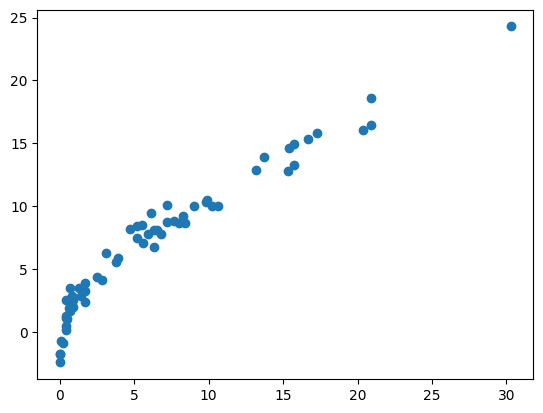

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elsreg = ElasticNet()
elsreg.fit(X_train_scaled,y_train)
y_pred=elsreg.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:", mae)
print("r2 Score:", r2)
plt.scatter(y_test,y_pred)

## Lasso CV Regression

Mean Absolute Error: 0.9630024676566873
r2 Score: 0.9611112947220234


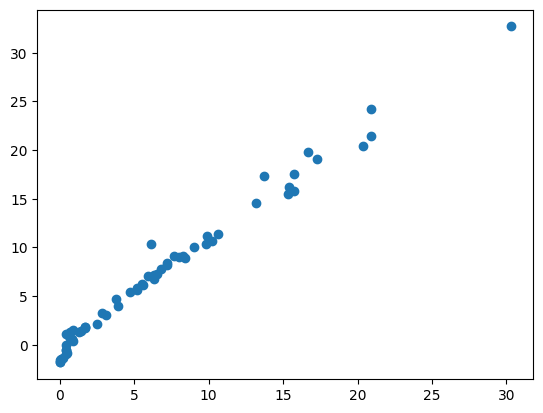

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lascvreg = LassoCV(cv=3)
lascvreg.fit(X_train_scaled,y_train)
y_pred = lascvreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:", mae)
print("r2 Score:", r2)
plt.scatter(y_test,y_pred)

## RidgeCV Regression

Mean Absolute Error: 0.9862070802884405
r2 Score: 0.9616458508455313


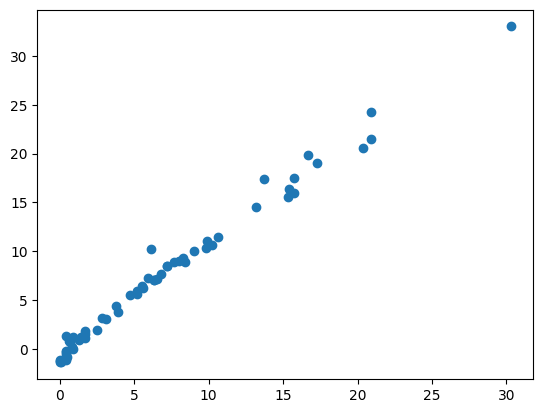

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
rigcvreg = RidgeCV(cv=5)
rigcvreg.fit(X_train_scaled,y_train)
y_pred = rigcvreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:", mae)
print("r2 Score:", r2)
plt.scatter(y_test,y_pred)

## ElasticNetCV Regression

Mean Absolute Error: 0.9658446127981584
r2 Score: 0.9635664846226284


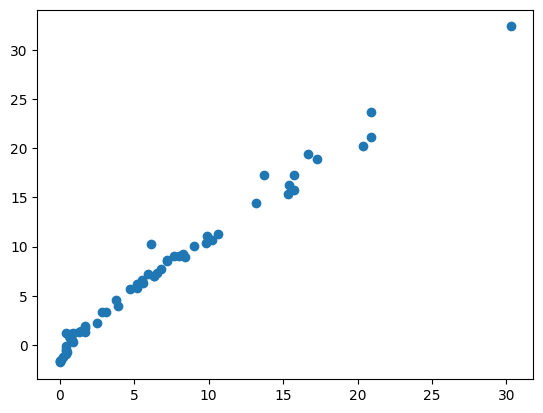

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
enetcvreg = ElasticNetCV(cv=5)
enetcvreg.fit(X_train_scaled,y_train)
y_pred = enetcvreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:", mae)
print("r2 Score:", r2)
plt.scatter(y_test,y_pred)

In [ ]:
import pickle
pickle.dump(ridreg, open('ridge.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl','wb'))

In [ ]:
!git config --global user.name "Divanshu-Bansal"
!git config --global user.email "divanshubansal05@gmail.com"

In [ ]:
from google.colab import userdata
Github_PAT = userdata.get('Github_PAT')

# Replace with your actual token, username, and repository name
token = Github_PAT
username = "Divanshu-Bansal"
repo = "Algerian_forest_fires_datase_Ridge_Lasso_Elastic_Regression"

!git remote set-url origin https://{token}@github.com/{username}/{repo}.git


In [ ]:
!git add .

In [ ]:
!git commit -m "Saving the Models"

[master c058cee] Saving the Models
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 ridge.pkl
 create mode 100644 scaler.pkl


In [ ]:
!git pull origin master --rebase

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 3.11 KiB | 113.00 KiB/s, done.
From https://github.com/Divanshu-Bansal/Algerian_forest_fires_datase_Ridge_Lasso_Elastic_Regression
 * branch            master     -> FETCH_HEAD
   0dd638a..f7151f8  master     -> origin/master
Successfully rebased and updated refs/heads/master.


In [ ]:
!git push origin master

Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.39 KiB | 1.39 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Divanshu-Bansal/Algerian_forest_fires_datase_Ridge_Lasso_Elastic_Regression.git
   f7151f8..c3405f7  master -> master
